In [1]:
#!pip install pandas matplotlib seaborn scipy numpy
import sys
print(sys.executable)
import matplotlib
print(matplotlib.__file__)
#!pip install pandas matplotlib seaborn scipy numpy


/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/bin/python
/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/lib/python3.11/site-packages/matplotlib/__init__.py


In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [4]:
!python --version

Python 3.11.9


In [7]:
CACHE_DIR = Path('../Data/Parquet')
CACHE_DIR.mkdir(exist_ok=True)

In [4]:
SECCHI_COLS = [
    "Cst_Cnt",
    "Cruise_ID",
    "Cruz_Sta",
    "Cast_ID",
    "Sta_ID",
    "Distance",
    "Date",
    "Time",
    "Lat_Dec",
    "Lon_Dec",
    "Ac_Line",
    "Bottom_D",
    "IntChl",
    "IntC14",
    "TimeZone",
    "Visibility",
    "Secchi",
]

DOWNCAST_COLS = [
    "ORD_OCC",
    "CAST_ID",
    "DATE_TIME_UTC",
    "DATE_TIME_PST",
    "LAT_DEC",
    "LON_DEC",
    "STA_ID",
    "STA",
    "LINE",
    "DEPTH",
    "PRESSURE",
    "ESTCHL_CRUISECORR",
    "ESTCHL_STACORR",
    "BAT",
    "XMISS",
    "SPAR",
    "PAR",
    "CHL_A",
    "PHAEO",
    "CAST_COUNT"
]

In [8]:
def load_or_cache(csv_path, parquet_path, usecols=None):
    parquet_path = Path(parquet_path)

    if parquet_path.exists():
        print(f"Loading cached: {parquet_path}")
        return pd.read_parquet(parquet_path)

    print(f"Reading CSV: {csv_path}")
    df = pd.read_csv(
        csv_path,
        usecols=usecols,
        low_memory=False
    )

    # Normalize object columns so Parquet doesn't choke
    obj_cols = df.select_dtypes(include="object").columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].astype("string")

    print(f"Caching → {parquet_path}")
    df.to_parquet(parquet_path)

    return df

data_downcast = load_or_cache(
    "../Data/downcast_all.csv",
    CACHE_DIR / "downcast.parquet",
    usecols=DOWNCAST_COLS
)

data_secchi = load_or_cache(
    "../Data/Secchi.csv",
    CACHE_DIR / "secchi.parquet",
    usecols=SECCHI_COLS
)


Loading cached: ../Data/Parquet/downcast.parquet
Loading cached: ../Data/Parquet/secchi.parquet


In [9]:
# Convert PAR to numeric if it's a string
if data_downcast["PAR"].dtype == "string":
    data_downcast["PAR"] = pd.to_numeric(data_downcast["PAR"], errors='coerce')

# Convert CAST_COUNT to numeric if it's a string
if data_downcast["CAST_COUNT"].dtype == "string":
    data_downcast["CAST_COUNT"] = pd.to_numeric(data_downcast["CAST_COUNT"], errors='coerce')

# Convert DEPTH to numeric if it's a string
if data_downcast["DEPTH"].dtype == "string":
    data_downcast["DEPTH"] = pd.to_numeric(data_downcast["DEPTH"], errors='coerce')

# Convert STA to numeric if it's a string
if data_downcast["STA"].dtype == "string":
    data_downcast["STA"] = pd.to_numeric(data_downcast["STA"], errors='coerce')

# Convert Secchi to numeric if it's a string
if data_secchi["Secchi"].dtype == "string":
    data_secchi["Secchi"] = pd.to_numeric(data_secchi["Secchi"], errors='coerce')

# Convert Cst_Cnt to numeric if it's a string (for consistency)
if data_secchi["Cst_Cnt"].dtype == "string":
    data_secchi["Cst_Cnt"] = pd.to_numeric(data_secchi["Cst_Cnt"], errors='coerce')

# Convert XMISS into numeric (in case it's a string)
if data_downcast["XMISS"].dtype == "string":
    data_downcast["XMISS"] = pd.to_numeric(data_downcast["XMISS"], errors='coerce')

# Convert BAT into numeric (in case it's a string)
if data_downcast["BAT"].dtype == "string":
    data_downcast["BAT"] = pd.to_numeric(data_downcast["BAT"], errors='coerce')

# Convert pressure into numeric (in case it's a string)
if data_downcast["PRESSURE"].dtype == "string":
    data_downcast["PRESSURE"] = pd.to_numeric(data_downcast["PRESSURE"], errors='coerce')

# Convert ESTCHL_CRUISECORR into numeric (in case it's a string)
if data_downcast["ESTCHL_CRUISECORR"].dtype == "string":
    data_downcast["ESTCHL_CRUISECORR"] = pd.to_numeric(data_downcast["ESTCHL_CRUISECORR"], errors='coerce')

# convert ESTCHL_STACORR into numeric (in case it's a string)
if data_downcast["ESTCHL_STACORR"].dtype == "string":
    data_downcast["ESTCHL_STACORR"] = pd.to_numeric(data_downcast["ESTCHL_STACORR"], errors='coerce')

# Convert CHL_A into numeric (in case it's a string)
if data_downcast["CHL_A"].dtype == "string":
    data_downcast["CHL_A"] = pd.to_numeric(data_downcast["CHL_A"], errors='coerce')

# Convert PHAEO into numeric (in case it's a string)
if data_downcast["PHAEO"].dtype == "string":
    data_downcast["PHAEO"] = pd.to_numeric(data_downcast["PHAEO"], errors='coerce')

# Convert SPAR into numeric (in case it's a string)
if data_downcast["SPAR"].dtype == "string":
    data_downcast["SPAR"] = pd.to_numeric(data_downcast["SPAR"], errors='coerce')

# Convert distance into numeric (in case it's a string)
if data_secchi["Distance"].dtype == "string":
    data_secchi["Distance"] = pd.to_numeric(data_secchi["Distance"], errors='coerce')


In [10]:
# Checking number of rows and columns
print("Downcast:", data_downcast.shape)
print("Secchi:", data_secchi.shape)

Downcast: (3800269, 20)
Secchi: (35644, 17)


In [11]:
# Merging the data

## Filtering the data so we only include secchi >0 and par >0 and not null
secchi_filtered = data_secchi[data_secchi["Secchi"].notna() & (data_secchi["Secchi"] > 0)]
downcast_filtered = data_downcast[data_downcast["PAR"].notna() & (data_downcast["PAR"] > 0)]

print(f"\nAfter filtering:")
print(f"Secchi filtered: {secchi_filtered.shape}")
print(f"Downcast filtered: {downcast_filtered.shape}")

# Keeping only necessary Cast count / ID 
valid_casts = set(secchi_filtered["Cst_Cnt"]) & set(downcast_filtered["CAST_COUNT"])
print(f"Number of overlapping casts: {len(valid_casts)}")

secchi_filtered = secchi_filtered[secchi_filtered["Cst_Cnt"].isin(valid_casts)]
downcast_filtered = downcast_filtered[downcast_filtered["CAST_COUNT"].isin(valid_casts)]

# Add sort helper column - downcast rows = 0, secchi rows = 1 (so secchi comes last)
downcast_filtered = downcast_filtered.copy()
downcast_filtered["_sort_order"] = 0

# Creating extra rows for each cast count for secchi
secchi_extra_rows = secchi_filtered.copy()
secchi_extra_rows = secchi_extra_rows.rename(columns={"Cst_Cnt": "CAST_COUNT"})
secchi_extra_rows["_sort_order"] = 1  # Secchi rows come last

# Fill all downcast rows with NA for the extra secchi rows
downcast_cols = data_downcast.columns.tolist()
for col in downcast_cols:
    if col != "CAST_COUNT":  # keep CAST_COUNT for merge
        secchi_extra_rows[col] = pd.NA

# Reorder columns so downcast columns come first
secchi_extra_rows = secchi_extra_rows[downcast_cols + ["_sort_order"] + [c for c in secchi_extra_rows.columns if c not in downcast_cols and c != "_sort_order"]]

# Merge
merged_df = pd.concat([downcast_filtered, secchi_extra_rows], ignore_index=True, sort=False)

# Sort by CAST_COUNT first, then by _sort_order (so secchi rows come at the end of each cast)
merged_df = merged_df.sort_values(by=["CAST_COUNT", "_sort_order"], ignore_index=True)

# Remove the helper column
merged_df = merged_df.drop(columns=["_sort_order"])

# Convert DEPTH and STA in merged_df to numeric (in case it's still a string from Secchi rows)
if merged_df["DEPTH"].dtype == "string" or merged_df["DEPTH"].dtype == "object":
    merged_df["DEPTH"] = pd.to_numeric(merged_df["DEPTH"], errors='coerce')

if merged_df["STA"].dtype == "string" or merged_df["STA"].dtype == "object":
    merged_df["STA"] = pd.to_numeric(merged_df["STA"], errors='coerce')


After filtering:
Secchi filtered: (5689, 17)
Downcast filtered: (3359981, 20)
Number of overlapping casts: 2774


# When threshold is 4.7% of light
This is also using only depth 2, if 2 is unavailable, it is skipping. Other idea is to use the shallowest depth and adjust the correlation

In [16]:
# ===== PHOTIC ZONE CALCULATION =====
print("\nCalculating photic zones...")

# Initialize PHOTIC_ZONE column as False for all rows
merged_df['PHOTIC_ZONE'] = False

# Counters for statistics
used_depth_2 = 0
used_shallowest = 0

# Process each cast
for cast_id in valid_casts:
    # Get all rows for this cast
    cast_mask = merged_df['CAST_COUNT'] == cast_id
    cast_data = merged_df[cast_mask].copy()
    
    # Filter to rows with valid PAR and DEPTH (excludes Secchi row)
    par_mask = cast_data['PAR'].notna() & cast_data['DEPTH'].notna() & (cast_data['DEPTH'] > 0)
    par_data = cast_data[par_mask].copy()
    
    if len(par_data) == 0:
        continue
    
    # Sort by depth
    par_data = par_data.sort_values('DEPTH')
    
    # Try to find depth = 2, otherwise use shallowest
    # Only use depth = 2 as baseline
    depth_2_rows = par_data[par_data['DEPTH'] == 2]

    if len(depth_2_rows) > 0:
        # Use depth 2 as baseline
        baseline_par = depth_2_rows['PAR'].iloc[0]
        used_depth_2 += 1
        
        # Calculate 4.7% threshold
        threshold_par = baseline_par * 0.045
        
        # Find first depth where PAR <= threshold
        below_threshold = par_data[par_data['PAR'] <= threshold_par]
        
        if len(below_threshold) > 0:
            # Get the index of the first row that crosses the threshold
            photic_idx = below_threshold.index[0]
            # Mark it as True in the main dataframe
            merged_df.loc[photic_idx, 'PHOTIC_ZONE'] = True
    else:
        # Skip this cast - no depth 2 available
        used_shallowest += 1

MERGED_PATH = Path("../Data/merged_dataset_organized_47photic.csv")
merged_df.to_csv(MERGED_PATH, index=False)
print(f"Merged dataset saved to {MERGED_PATH}, shape: {merged_df.shape}")

# Print statistics
photic_count = merged_df['PHOTIC_ZONE'].sum()
print(f"\nPhotic zone statistics:")
print(f"Number of photic zone depths marked: {photic_count}")
print(f"Number of unique casts: {len(valid_casts)}")
print(f"Casts using depth=2 as baseline: {used_depth_2}")
print(f"Casts using shallowest depth as baseline: {used_shallowest}")


Calculating photic zones...
Merged dataset saved to ../Data/merged_dataset_organized_47photic.csv, shape: (1255966, 37)

Photic zone statistics:
Number of photic zone depths marked: 1970
Number of unique casts: 2774
Casts using depth=2 as baseline: 2285
Casts using shallowest depth as baseline: 489


In [17]:
# ===== CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI BY SHORE PROXIMITY =====
print("\n" + "="*60)
print("CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI")
print("BY SHORE PROXIMITY (STA <= 60 = Near Shore, STA > 60 = Offshore)")
print("="*60)

# Get photic zone data
photic_zone_data = merged_df[merged_df['PHOTIC_ZONE'] == True].copy()

# For each cast, match photic depth with Secchi value
correlation_data = []

for cast_id in valid_casts:
    # Get photic zone row for this cast
    photic_row = photic_zone_data[photic_zone_data['CAST_COUNT'] == cast_id]
    if len(photic_row) == 0:
        continue
    
    # Get Secchi value for this cast
    cast_rows = merged_df[merged_df['CAST_COUNT'] == cast_id]
    secchi_row = cast_rows[cast_rows['Secchi'].notna()]
    
    if len(secchi_row) == 0:
        continue
    
    photic_depth = photic_row['DEPTH'].iloc[0]
    secchi_value = secchi_row['Secchi'].iloc[0]
    sta_value = photic_row['STA'].iloc[0]
    
    # Determine shore proximity
    if pd.notna(sta_value):
        shore_proximity = 'Near Shore' if sta_value <= 60 else 'Offshore'
    else:
        shore_proximity = 'Unknown'
    
    correlation_data.append({
        'CAST_COUNT': cast_id,
        'PHOTIC_DEPTH': photic_depth,
        'SECCHI': secchi_value,
        'STA': sta_value,
        'SHORE_PROXIMITY': shore_proximity
    })

corr_df = pd.DataFrame(correlation_data)
corr_df["PHOTIC_DEPTH"] = pd.to_numeric(corr_df["PHOTIC_DEPTH"], errors="coerce")
corr_df["SECCHI"] = pd.to_numeric(corr_df["SECCHI"], errors="coerce")

# Save correlation data
CORR_PATH = Path("../Data/photic_depth_secchi_correlation_by_shore.csv")
corr_df.to_csv(CORR_PATH, index=False)
print(f"\nCorrelation data saved to {CORR_PATH}")
print(f"Total matched pairs: {len(corr_df)}")

# Split by shore proximity
near_shore_df = corr_df[corr_df['SHORE_PROXIMITY'] == 'Near Shore']
offshore_df = corr_df[corr_df['SHORE_PROXIMITY'] == 'Offshore']

print(f"\nNear Shore (STA <= 60): {len(near_shore_df)} observations")
print(f"Offshore (STA > 60): {len(offshore_df)} observations")

# Calculate correlations for OVERALL data
if len(corr_df) > 0:
    print("\n" + "="*60)
    print("OVERALL CORRELATIONS (All Data)")
    print("="*60)
    
    pearson_overall = stats.pearsonr(corr_df['PHOTIC_DEPTH'], corr_df['SECCHI'])
    spearman_overall = stats.spearmanr(corr_df['PHOTIC_DEPTH'], corr_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_overall[0]:.4f}, p-value = {pearson_overall[1]:.4e}")
    print(f"  Spearman ρ = {spearman_overall[0]:.4f}, p-value = {spearman_overall[1]:.4e}")

# Calculate correlations for NEAR SHORE
if len(near_shore_df) > 1:
    print("\n" + "="*60)
    print("NEAR SHORE CORRELATIONS (STA <= 60)")
    print("="*60)
    
    pearson_near = stats.pearsonr(near_shore_df['PHOTIC_DEPTH'], near_shore_df['SECCHI'])
    spearman_near = stats.spearmanr(near_shore_df['PHOTIC_DEPTH'], near_shore_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_near[0]:.4f}, p-value = {pearson_near[1]:.4e}")
    print(f"  Spearman ρ = {spearman_near[0]:.4f}, p-value = {spearman_near[1]:.4e}")
else:
    print("\nNot enough Near Shore data for correlation")
    pearson_near = (0, 1)  # dummy values for plotting

# Calculate correlations for OFFSHORE
if len(offshore_df) > 1:
    print("\n" + "="*60)
    print("OFFSHORE CORRELATIONS (STA > 60)")
    print("="*60)
    
    pearson_off = stats.pearsonr(offshore_df['PHOTIC_DEPTH'], offshore_df['SECCHI'])
    spearman_off = stats.spearmanr(offshore_df['PHOTIC_DEPTH'], offshore_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_off[0]:.4f}, p-value = {pearson_off[1]:.4e}")
    print(f"  Spearman ρ = {spearman_off[0]:.4f}, p-value = {spearman_off[1]:.4e}")
else:
    print("\nNot enough Offshore data for correlation")
    pearson_off = (0, 1)  # dummy values for plotting


CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI
BY SHORE PROXIMITY (STA <= 60 = Near Shore, STA > 60 = Offshore)

Correlation data saved to ../Data/photic_depth_secchi_correlation_by_shore.csv
Total matched pairs: 1970

Near Shore (STA <= 60): 1101 observations
Offshore (STA > 60): 869 observations

OVERALL CORRELATIONS (All Data)

Photic Depth vs Secchi:
  Pearson r = 0.7310, p-value = 0.0000e+00
  Spearman ρ = 0.7626, p-value = 0.0000e+00

NEAR SHORE CORRELATIONS (STA <= 60)

Photic Depth vs Secchi:
  Pearson r = 0.6652, p-value = 1.3709e-141
  Spearman ρ = 0.6718, p-value = 1.9587e-145

OFFSHORE CORRELATIONS (STA > 60)

Photic Depth vs Secchi:
  Pearson r = 0.5781, p-value = 1.2197e-78
  Spearman ρ = 0.6298, p-value = 3.1809e-97



Creating visualizations...
Visualization saved to ../results/47photic_depth_secchi_shore_comparison.png


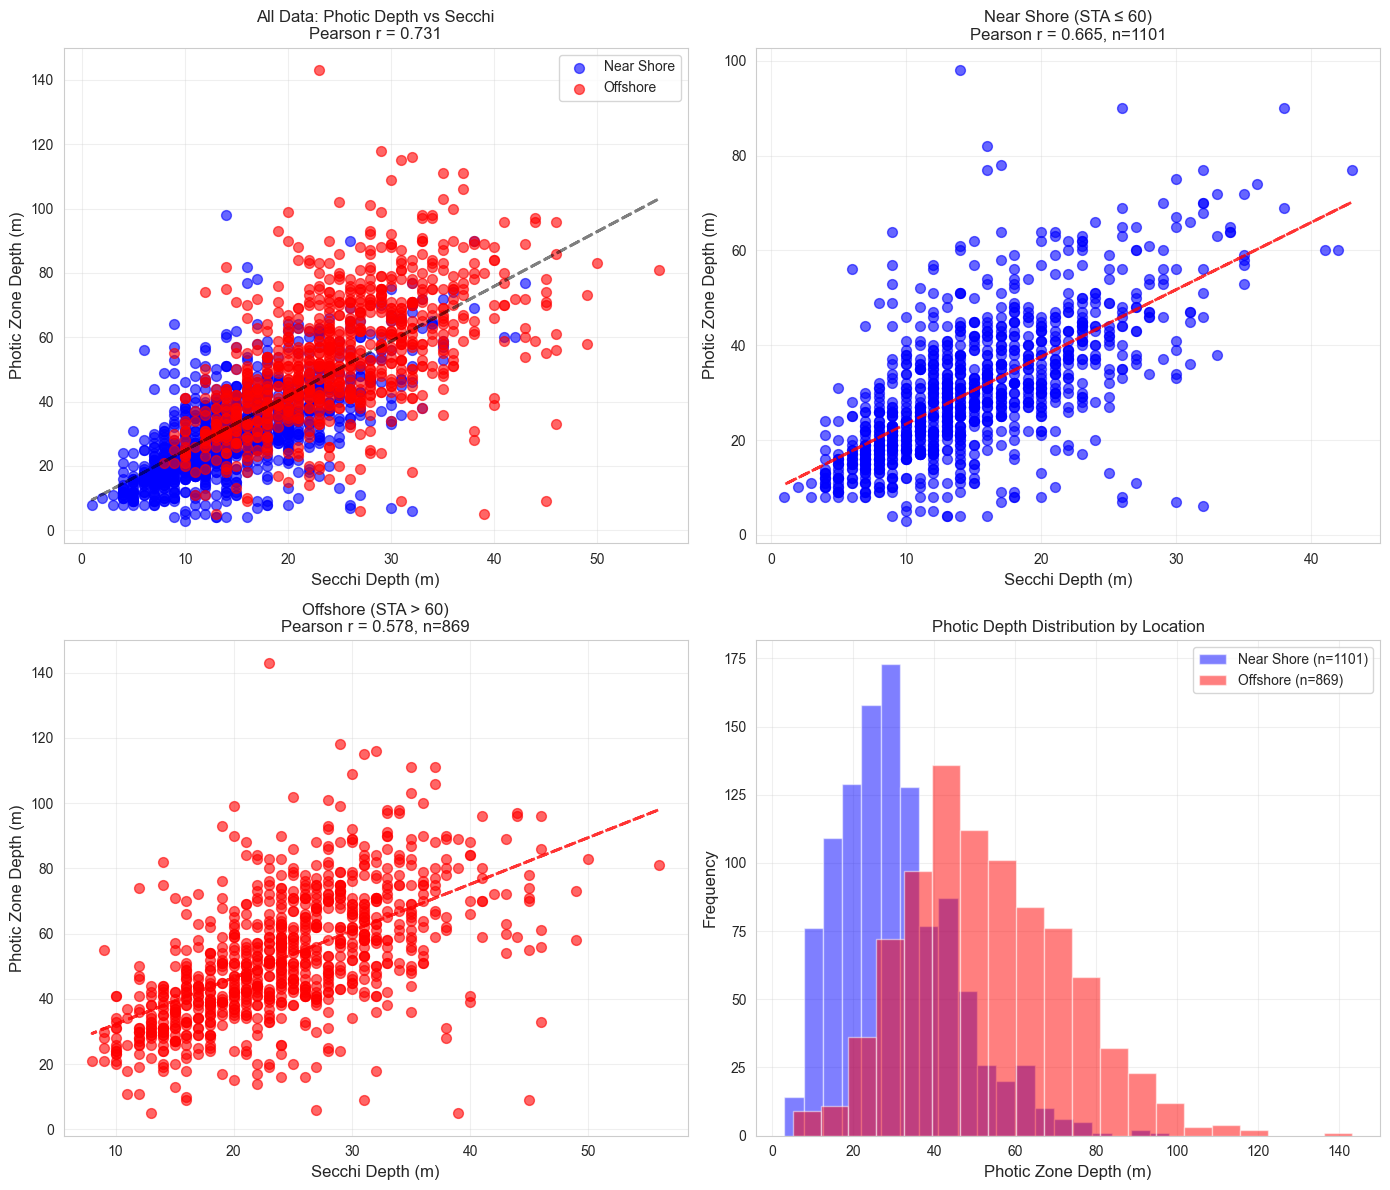

In [25]:
# ===== VISUALIZATIONS =====
print("\nCreating visualizations...")

# Set up the plotting style
sns.set_style("whitegrid")

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Overall scatter plot with color by shore proximity
if len(corr_df) > 0:
    for proximity, color in [('Near Shore', 'blue'), ('Offshore', 'red')]:
        subset = corr_df[corr_df['SHORE_PROXIMITY'] == proximity]
        if len(subset) > 0:
            axes[0, 0].scatter(subset['SECCHI'], subset['PHOTIC_DEPTH'], 
                             alpha=0.6, s=50, c=color, label=proximity)
    
    axes[0, 0].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[0, 0].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[0, 0].set_title(f'All Data: Photic Depth vs Secchi\nPearson r = {pearson_overall[0]:.3f}', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add overall regression line
    z_all = np.polyfit(corr_df['SECCHI'], corr_df['PHOTIC_DEPTH'], 1)
    p_all = np.poly1d(z_all)
    axes[0, 0].plot(corr_df['SECCHI'], p_all(corr_df['SECCHI']), 
                   "k--", alpha=0.5, linewidth=2, label='Overall fit')

# Plot 2: Near Shore only
if len(near_shore_df) > 1:
    axes[0, 1].scatter(near_shore_df['SECCHI'], near_shore_df['PHOTIC_DEPTH'], 
                      alpha=0.6, s=50, color='blue')
    axes[0, 1].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[0, 1].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[0, 1].set_title(f'Near Shore (STA ≤ 60)\nPearson r = {pearson_near[0]:.3f}, n={len(near_shore_df)}', fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Add regression line
    z_near = np.polyfit(near_shore_df['SECCHI'], near_shore_df['PHOTIC_DEPTH'], 1)
    p_near = np.poly1d(z_near)
    axes[0, 1].plot(near_shore_df['SECCHI'], p_near(near_shore_df['SECCHI']), 
                   "r--", alpha=0.8, linewidth=2)

# Plot 3: Offshore only
if len(offshore_df) > 1:
    axes[1, 0].scatter(offshore_df['SECCHI'], offshore_df['PHOTIC_DEPTH'], 
                      alpha=0.6, s=50, color='red')
    axes[1, 0].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[1, 0].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[1, 0].set_title(f'Offshore (STA > 60)\nPearson r = {pearson_off[0]:.3f}, n={len(offshore_df)}', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add regression line
    z_off = np.polyfit(offshore_df['SECCHI'], offshore_df['PHOTIC_DEPTH'], 1)
    p_off = np.poly1d(z_off)
    axes[1, 0].plot(offshore_df['SECCHI'], p_off(offshore_df['SECCHI']), 
                   "r--", alpha=0.8, linewidth=2)

# Plot 4: Distribution comparison
axes[1, 1].hist(near_shore_df['PHOTIC_DEPTH'], bins=20, alpha=0.5, 
               label=f'Near Shore (n={len(near_shore_df)})', color='blue')
axes[1, 1].hist(offshore_df['PHOTIC_DEPTH'], bins=20, alpha=0.5, 
               label=f'Offshore (n={len(offshore_df)})', color='red')
axes[1, 1].set_xlabel('Photic Zone Depth (m)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Photic Depth Distribution by Location', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

PLOT_PATH = Path("../results/47photic_depth_secchi_shore_comparison.png")
plt.savefig(PLOT_PATH, dpi=300, bbox_inches='tight')
print(f"Visualization saved to {PLOT_PATH}")

# For just 1% of Light
again we are just usnig 2m as the baseline nothing else

In [ ]:
# ===== PHOTIC ZONE CALCULATION =====
print("\nCalculating photic zones...")

# Initialize PHOTIC_ZONE column as False for all rows
merged_df['PHOTIC_ZONE'] = False

# Counters for statistics
used_depth_2 = 0
used_shallowest = 0

# Process each cast
for cast_id in valid_casts:
    # Get all rows for this cast
    cast_mask = merged_df['CAST_COUNT'] == cast_id
    cast_data = merged_df[cast_mask].copy()
    
    # Filter to rows with valid PAR and DEPTH (excludes Secchi row)
    par_mask = cast_data['PAR'].notna() & cast_data['DEPTH'].notna() & (cast_data['DEPTH'] > 0)
    par_data = cast_data[par_mask].copy()
    
    if len(par_data) == 0:
        continue
    
    # Sort by depth
    par_data = par_data.sort_values('DEPTH')
    
    # Try to find depth = 2, otherwise use shallowest
    # Only use depth = 2 as baseline
    depth_2_rows = par_data[par_data['DEPTH'] == 2]

    if len(depth_2_rows) > 0:
        # Use depth 2 as baseline
        baseline_par = depth_2_rows['PAR'].iloc[0]
        used_depth_2 += 1
        
        # Calculate 1% threshold
        threshold_par = baseline_par * 0.01
        
        # Find first depth where PAR <= threshold
        below_threshold = par_data[par_data['PAR'] <= threshold_par]
        
        if len(below_threshold) > 0:
            # Get the index of the first row that crosses the threshold
            photic_idx = below_threshold.index[0]
            # Mark it as True in the main dataframe
            merged_df.loc[photic_idx, 'PHOTIC_ZONE'] = True
    else:
        # Skip this cast - no depth 2 available
        used_shallowest += 1

MERGED_PATH = Path("../Data/merged_dataset_organized_1photic.csv")
merged_df.to_csv(MERGED_PATH, index=False)
print(f"Merged dataset saved to {MERGED_PATH}, shape: {merged_df.shape}")

# Print statistics
photic_count = merged_df['PHOTIC_ZONE'].sum()
print(f"\nPhotic zone statistics:")
print(f"Number of photic zone depths marked: {photic_count}")
print(f"Number of unique casts: {len(valid_casts)}")
print(f"Casts using depth=2 as baseline: {used_depth_2}")
print(f"Casts using shallowest depth as baseline: {used_shallowest}")


Calculating photic zones...
Merged dataset saved to ../Data/merged_dataset_organized_1photic.csv, shape: (1255966, 37)

Photic zone statistics:
Number of photic zone depths marked: 1911
Number of unique casts: 2774
Casts using depth=2 as baseline: 2285
Casts using shallowest depth as baseline: 489


In [30]:
# ===== CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI BY SHORE PROXIMITY =====
print("\n" + "="*60)
print("CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI")
print("BY SHORE PROXIMITY (STA <= 60 = Near Shore, STA > 60 = Offshore)")
print("="*60)

# Get photic zone data
photic_zone_data = merged_df[merged_df['PHOTIC_ZONE'] == True].copy()

# For each cast, match photic depth with Secchi value
correlation_data = []

for cast_id in valid_casts:
    # Get photic zone row for this cast
    photic_row = photic_zone_data[photic_zone_data['CAST_COUNT'] == cast_id]
    if len(photic_row) == 0:
        continue
    
    # Get Secchi value for this cast
    cast_rows = merged_df[merged_df['CAST_COUNT'] == cast_id]
    secchi_row = cast_rows[cast_rows['Secchi'].notna()]
    
    if len(secchi_row) == 0:
        continue
    
    photic_depth = photic_row['DEPTH'].iloc[0]
    secchi_value = secchi_row['Secchi'].iloc[0]
    sta_value = photic_row['STA'].iloc[0]
    
    # Determine shore proximity
    if pd.notna(sta_value):
        shore_proximity = 'Near Shore' if sta_value <= 60 else 'Offshore'
    else:
        shore_proximity = 'Unknown'
    
    correlation_data.append({
        'CAST_COUNT': cast_id,
        'PHOTIC_DEPTH': photic_depth,
        'SECCHI': secchi_value,
        'STA': sta_value,
        'SHORE_PROXIMITY': shore_proximity
    })

corr_df = pd.DataFrame(correlation_data)
corr_df["PHOTIC_DEPTH"] = pd.to_numeric(corr_df["PHOTIC_DEPTH"], errors="coerce")
corr_df["SECCHI"] = pd.to_numeric(corr_df["SECCHI"], errors="coerce")

# Save correlation data
CORR_PATH = Path("../Data/1photic_depth_secchi_correlation_by_shore.csv")
corr_df.to_csv(CORR_PATH, index=False)
print(f"\nCorrelation data saved to {CORR_PATH}")
print(f"Total matched pairs: {len(corr_df)}")

# Split by shore proximity
near_shore_df = corr_df[corr_df['SHORE_PROXIMITY'] == 'Near Shore']
offshore_df = corr_df[corr_df['SHORE_PROXIMITY'] == 'Offshore']

print(f"\nNear Shore (STA <= 60): {len(near_shore_df)} observations")
print(f"Offshore (STA > 60): {len(offshore_df)} observations")

# Calculate correlations for OVERALL data
if len(corr_df) > 0:
    print("\n" + "="*60)
    print("OVERALL CORRELATIONS (All Data)")
    print("="*60)
    
    pearson_overall = stats.pearsonr(corr_df['PHOTIC_DEPTH'], corr_df['SECCHI'])
    spearman_overall = stats.spearmanr(corr_df['PHOTIC_DEPTH'], corr_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_overall[0]:.4f}, p-value = {pearson_overall[1]:.4e}")
    print(f"  Spearman ρ = {spearman_overall[0]:.4f}, p-value = {spearman_overall[1]:.4e}")

# Calculate correlations for NEAR SHORE
if len(near_shore_df) > 1:
    print("\n" + "="*60)
    print("NEAR SHORE CORRELATIONS (STA <= 60)")
    print("="*60)
    
    pearson_near = stats.pearsonr(near_shore_df['PHOTIC_DEPTH'], near_shore_df['SECCHI'])
    spearman_near = stats.spearmanr(near_shore_df['PHOTIC_DEPTH'], near_shore_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_near[0]:.4f}, p-value = {pearson_near[1]:.4e}")
    print(f"  Spearman ρ = {spearman_near[0]:.4f}, p-value = {spearman_near[1]:.4e}")
else:
    print("\nNot enough Near Shore data for correlation")
    pearson_near = (0, 1)  # dummy values for plotting

# Calculate correlations for OFFSHORE
if len(offshore_df) > 1:
    print("\n" + "="*60)
    print("OFFSHORE CORRELATIONS (STA > 60)")
    print("="*60)
    
    pearson_off = stats.pearsonr(offshore_df['PHOTIC_DEPTH'], offshore_df['SECCHI'])
    spearman_off = stats.spearmanr(offshore_df['PHOTIC_DEPTH'], offshore_df['SECCHI'])
    
    print(f"\nPhotic Depth vs Secchi:")
    print(f"  Pearson r = {pearson_off[0]:.4f}, p-value = {pearson_off[1]:.4e}")
    print(f"  Spearman ρ = {spearman_off[0]:.4f}, p-value = {spearman_off[1]:.4e}")
else:
    print("\nNot enough Offshore data for correlation")
    pearson_off = (0, 1)  # dummy values for plotting


CORRELATION ANALYSIS: PHOTIC DEPTH vs SECCHI
BY SHORE PROXIMITY (STA <= 60 = Near Shore, STA > 60 = Offshore)

Correlation data saved to ../Data/1photic_depth_secchi_correlation_by_shore.csv
Total matched pairs: 1911

Near Shore (STA <= 60): 1046 observations
Offshore (STA > 60): 865 observations

OVERALL CORRELATIONS (All Data)

Photic Depth vs Secchi:
  Pearson r = 0.5646, p-value = 2.4854e-161
  Spearman ρ = 0.7268, p-value = 0.0000e+00

NEAR SHORE CORRELATIONS (STA <= 60)

Photic Depth vs Secchi:
  Pearson r = 0.4484, p-value = 7.1682e-53
  Spearman ρ = 0.6154, p-value = 4.8967e-110

OFFSHORE CORRELATIONS (STA > 60)

Photic Depth vs Secchi:
  Pearson r = 0.4031, p-value = 4.0070e-35
  Spearman ρ = 0.6053, p-value = 1.3952e-87



Creating visualizations...
Visualization saved to ../results/1photic_depth_secchi_shore_comparison.png


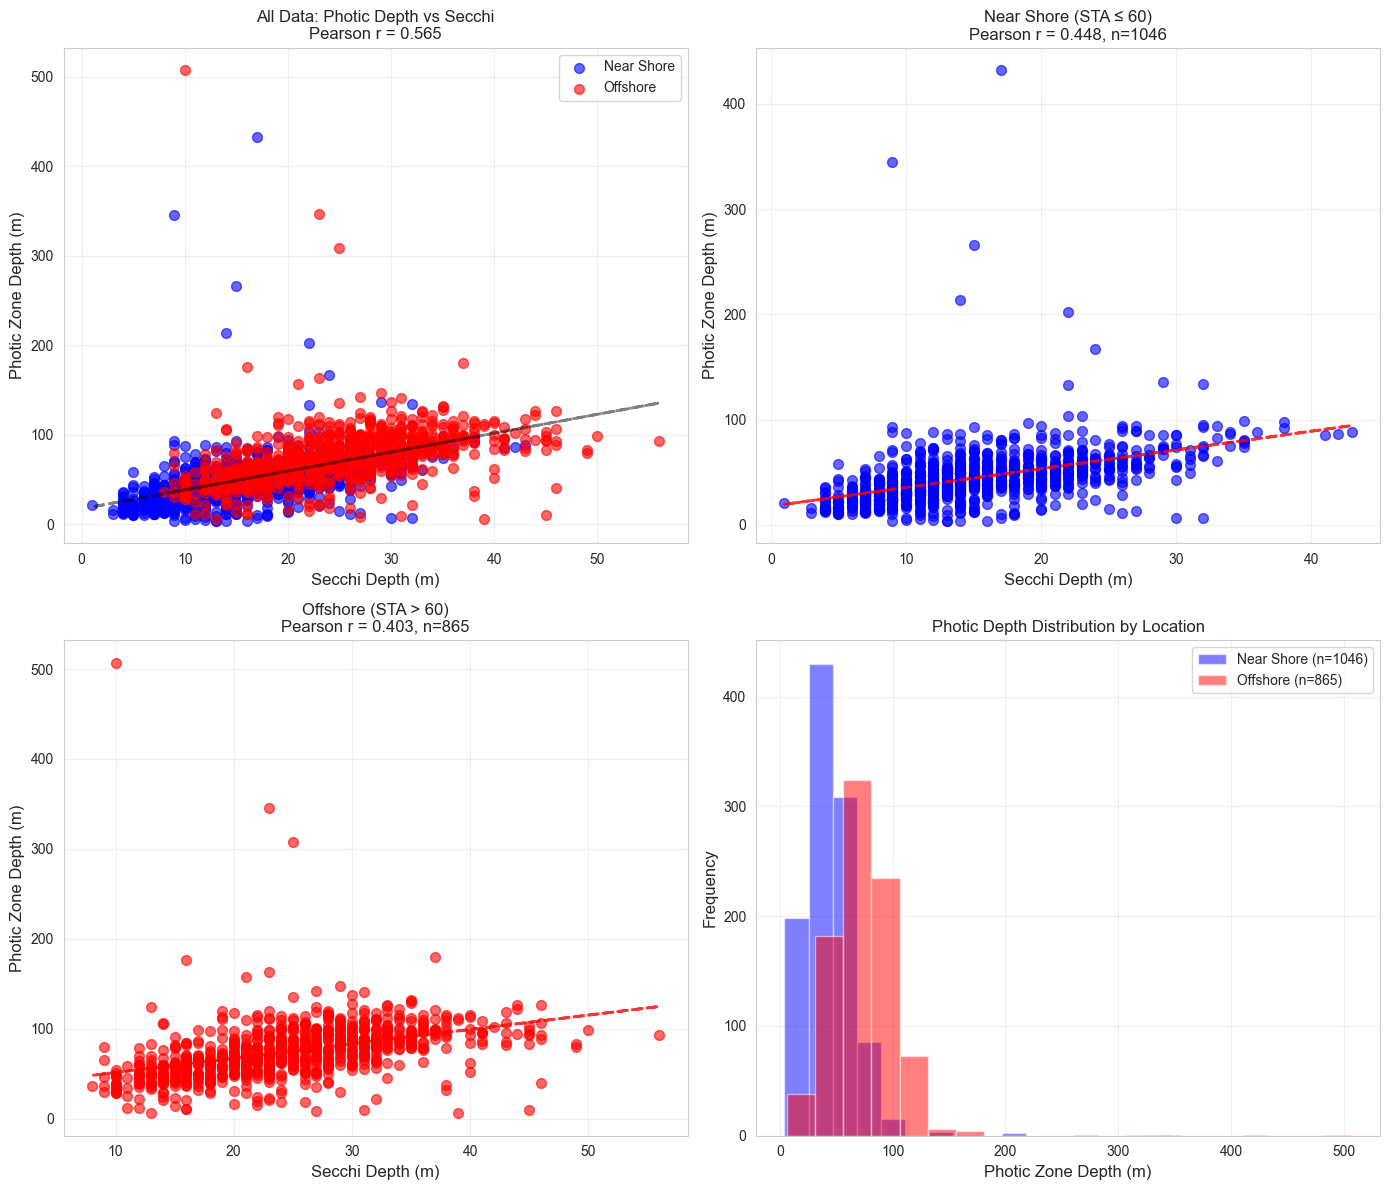

In [31]:
# ===== VISUALIZATIONS =====
print("\nCreating visualizations...")

# Set up the plotting style
sns.set_style("whitegrid")

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Overall scatter plot with color by shore proximity
if len(corr_df) > 0:
    for proximity, color in [('Near Shore', 'blue'), ('Offshore', 'red')]:
        subset = corr_df[corr_df['SHORE_PROXIMITY'] == proximity]
        if len(subset) > 0:
            axes[0, 0].scatter(subset['SECCHI'], subset['PHOTIC_DEPTH'], 
                             alpha=0.6, s=50, c=color, label=proximity)
    
    axes[0, 0].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[0, 0].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[0, 0].set_title(f'All Data: Photic Depth vs Secchi\nPearson r = {pearson_overall[0]:.3f}', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add overall regression line
    z_all = np.polyfit(corr_df['SECCHI'], corr_df['PHOTIC_DEPTH'], 1)
    p_all = np.poly1d(z_all)
    axes[0, 0].plot(corr_df['SECCHI'], p_all(corr_df['SECCHI']), 
                   "k--", alpha=0.5, linewidth=2, label='Overall fit')

# Plot 2: Near Shore only
if len(near_shore_df) > 1:
    axes[0, 1].scatter(near_shore_df['SECCHI'], near_shore_df['PHOTIC_DEPTH'], 
                      alpha=0.6, s=50, color='blue')
    axes[0, 1].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[0, 1].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[0, 1].set_title(f'Near Shore (STA ≤ 60)\nPearson r = {pearson_near[0]:.3f}, n={len(near_shore_df)}', fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Add regression line
    z_near = np.polyfit(near_shore_df['SECCHI'], near_shore_df['PHOTIC_DEPTH'], 1)
    p_near = np.poly1d(z_near)
    axes[0, 1].plot(near_shore_df['SECCHI'], p_near(near_shore_df['SECCHI']), 
                   "r--", alpha=0.8, linewidth=2)

# Plot 3: Offshore only
if len(offshore_df) > 1:
    axes[1, 0].scatter(offshore_df['SECCHI'], offshore_df['PHOTIC_DEPTH'], 
                      alpha=0.6, s=50, color='red')
    axes[1, 0].set_xlabel('Secchi Depth (m)', fontsize=12)
    axes[1, 0].set_ylabel('Photic Zone Depth (m)', fontsize=12)
    axes[1, 0].set_title(f'Offshore (STA > 60)\nPearson r = {pearson_off[0]:.3f}, n={len(offshore_df)}', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add regression line
    z_off = np.polyfit(offshore_df['SECCHI'], offshore_df['PHOTIC_DEPTH'], 1)
    p_off = np.poly1d(z_off)
    axes[1, 0].plot(offshore_df['SECCHI'], p_off(offshore_df['SECCHI']), 
                   "r--", alpha=0.8, linewidth=2)

# Plot 4: Distribution comparison
axes[1, 1].hist(near_shore_df['PHOTIC_DEPTH'], bins=20, alpha=0.5, 
               label=f'Near Shore (n={len(near_shore_df)})', color='blue')
axes[1, 1].hist(offshore_df['PHOTIC_DEPTH'], bins=20, alpha=0.5, 
               label=f'Offshore (n={len(offshore_df)})', color='red')
axes[1, 1].set_xlabel('Photic Zone Depth (m)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Photic Depth Distribution by Location', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

PLOT_PATH = Path("../results/1photic_depth_secchi_shore_comparison.png")
plt.savefig(PLOT_PATH, dpi=300, bbox_inches='tight')
print(f"Visualization saved to {PLOT_PATH}")